# 威斯康辛州乳腺癌数据集分类实验
## Breast Cancer Wisconsin Classification

**数据来源**: [Kaggle - Breast Cancer Wisconsin Data](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

**实验目标**: 对乳腺癌肿瘤（恶性/良性）进行二分类，比较以下四种算法的性能：
1. 逻辑回归 (Logistic Regression)
2. 支持向量机 (SVM)
3. 随机森林 (Random Forest)
4. XGBoost

---

In [1]:
# ============================================================
# 导入库
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 机器学习
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# 全局绘图风格
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 调色板
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
CMAP_BLUE = 'Blues'

print(' 所有库导入成功')

 所有库导入成功


---
## 1. 数据加载与初步探索


In [2]:
# ============================================================
# 1.1 加载数据
# ============================================================
DATA_PATH = '../data/data.csv'

df = pd.read_csv(DATA_PATH)

# 删除无用列（id列 和 全空列 Unnamed: 32）
df.drop(columns=['id', 'Unnamed: 32'], errors='ignore', inplace=True)

print(f'数据形状: {df.shape}')
print(f'目标列唯一值: {df["diagnosis"].unique()}')
df.head()

数据形状: (569, 31)
目标列唯一值: ['M' 'B']


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# ============================================================
# 1.2 基本信息
# ============================================================
print('=' * 55)
print('数据基本信息')
print('=' * 55)
print(f'样本数量  : {df.shape[0]}')
print(f'特征数量  : {df.shape[1] - 1}')
print(f'缺失值总数: {df.isnull().sum().sum()}')
print('\n各类别数量:')
print(df['diagnosis'].value_counts())
print('\n数值统计摘要:')
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

数据基本信息
样本数量  : 569
特征数量  : 30
缺失值总数: 0

各类别数量:
B    357
M    212
Name: diagnosis, dtype: int64

数值统计摘要:


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
fractal_dimension_mean,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


---
## 2. 数据可视化分析

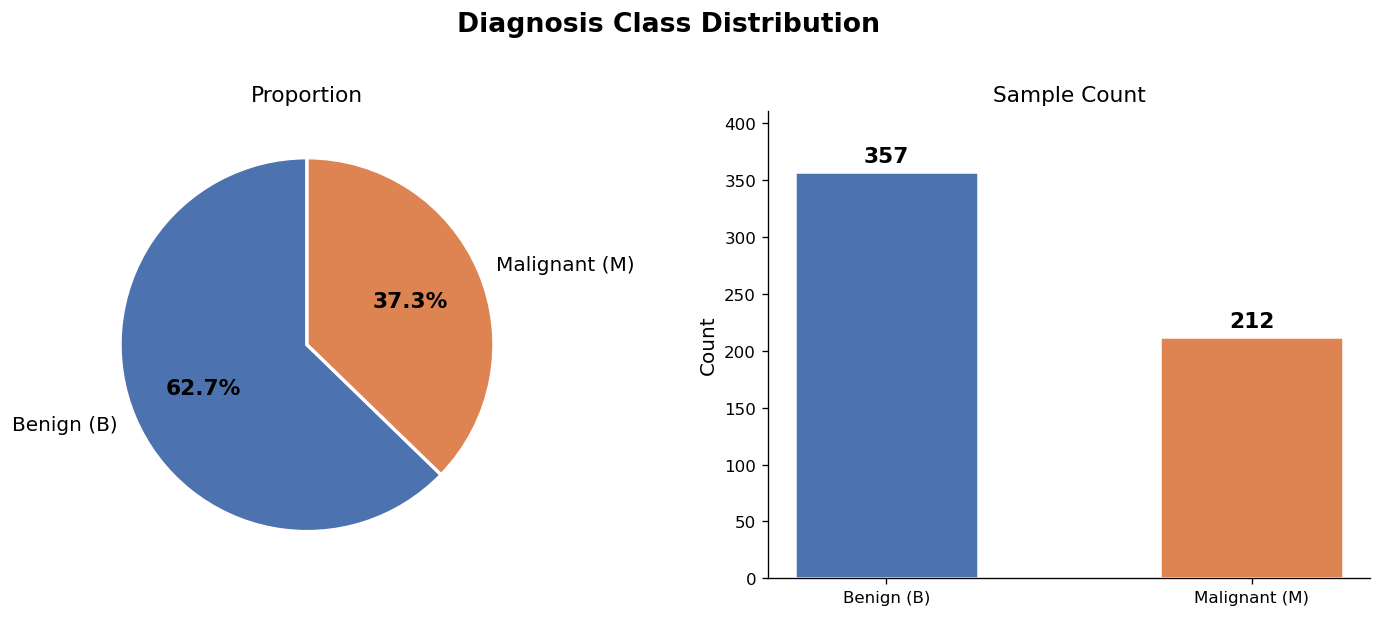

In [4]:
# ============================================================
# 2.1 类别分布（饼图 + 条形图）
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Diagnosis Class Distribution', fontsize=16, fontweight='bold', y=1.02)

counts = df['diagnosis'].value_counts()
labels = ['Benign (B)', 'Malignant (M)']
colors = ['#4C72B0', '#DD8452']

# 饼图
wedges, texts, autotexts = axes[0].pie(
    counts.values, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[0].set_title('Proportion', fontsize=13)

# 条形图
bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='white',
                   linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Sample Count', fontsize=13)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.savefig('../report/fig_01_class_distribution.png', bbox_inches='tight')
plt.show()

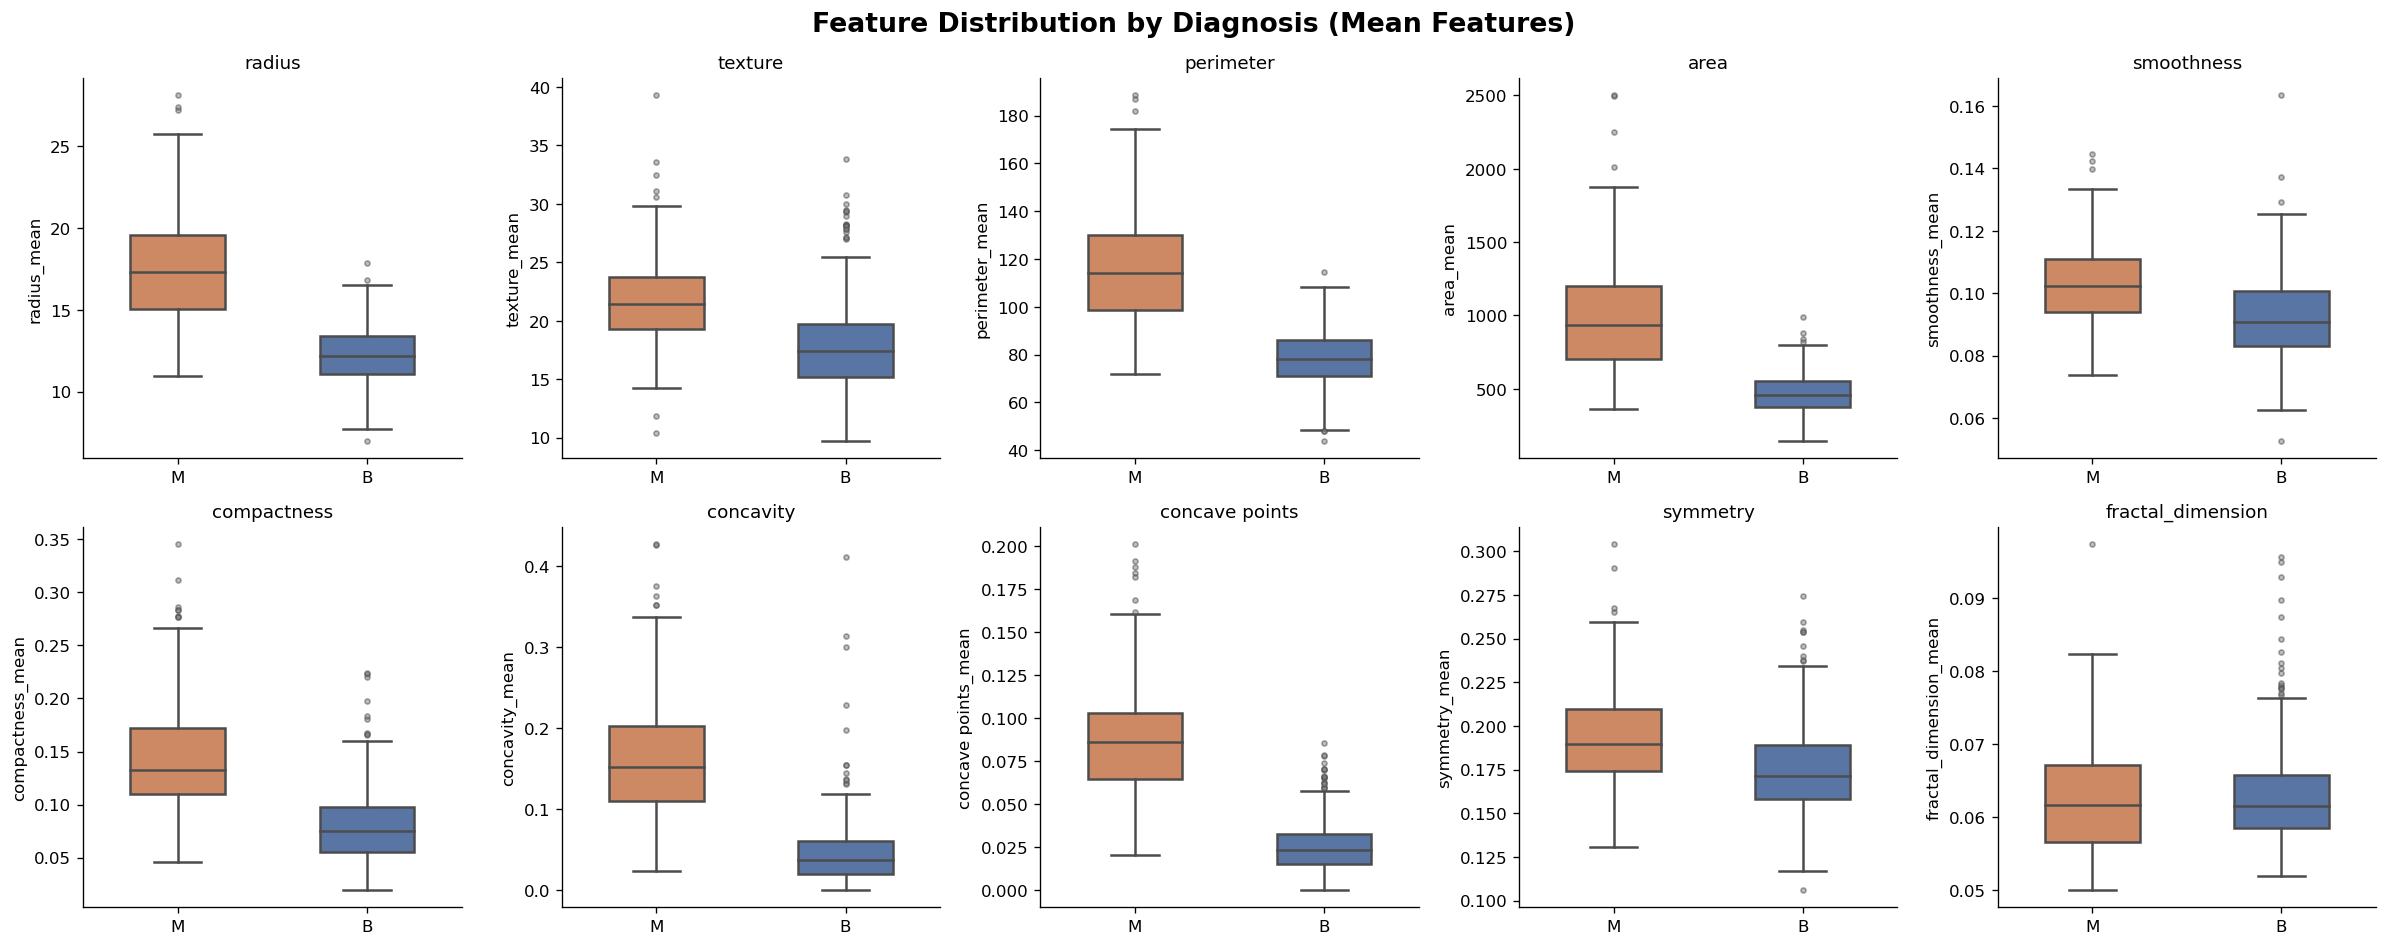

In [5]:
# ============================================================
# 2.2 关键特征箱线图（mean 特征）
# ============================================================
mean_features = [c for c in df.columns if '_mean' in c]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Feature Distribution by Diagnosis (Mean Features)',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

palette = {'B': '#4C72B0', 'M': '#DD8452'}

for i, feat in enumerate(mean_features[:10]):
    sns.boxplot(
        data=df, x='diagnosis', y=feat, ax=axes[i],
        palette=palette, width=0.5,
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5)
    )
    axes[i].set_title(feat.replace('_mean', ''), fontsize=11)
    axes[i].set_xlabel('')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../report/fig_02_boxplot_mean_features.png', bbox_inches='tight')
plt.show()

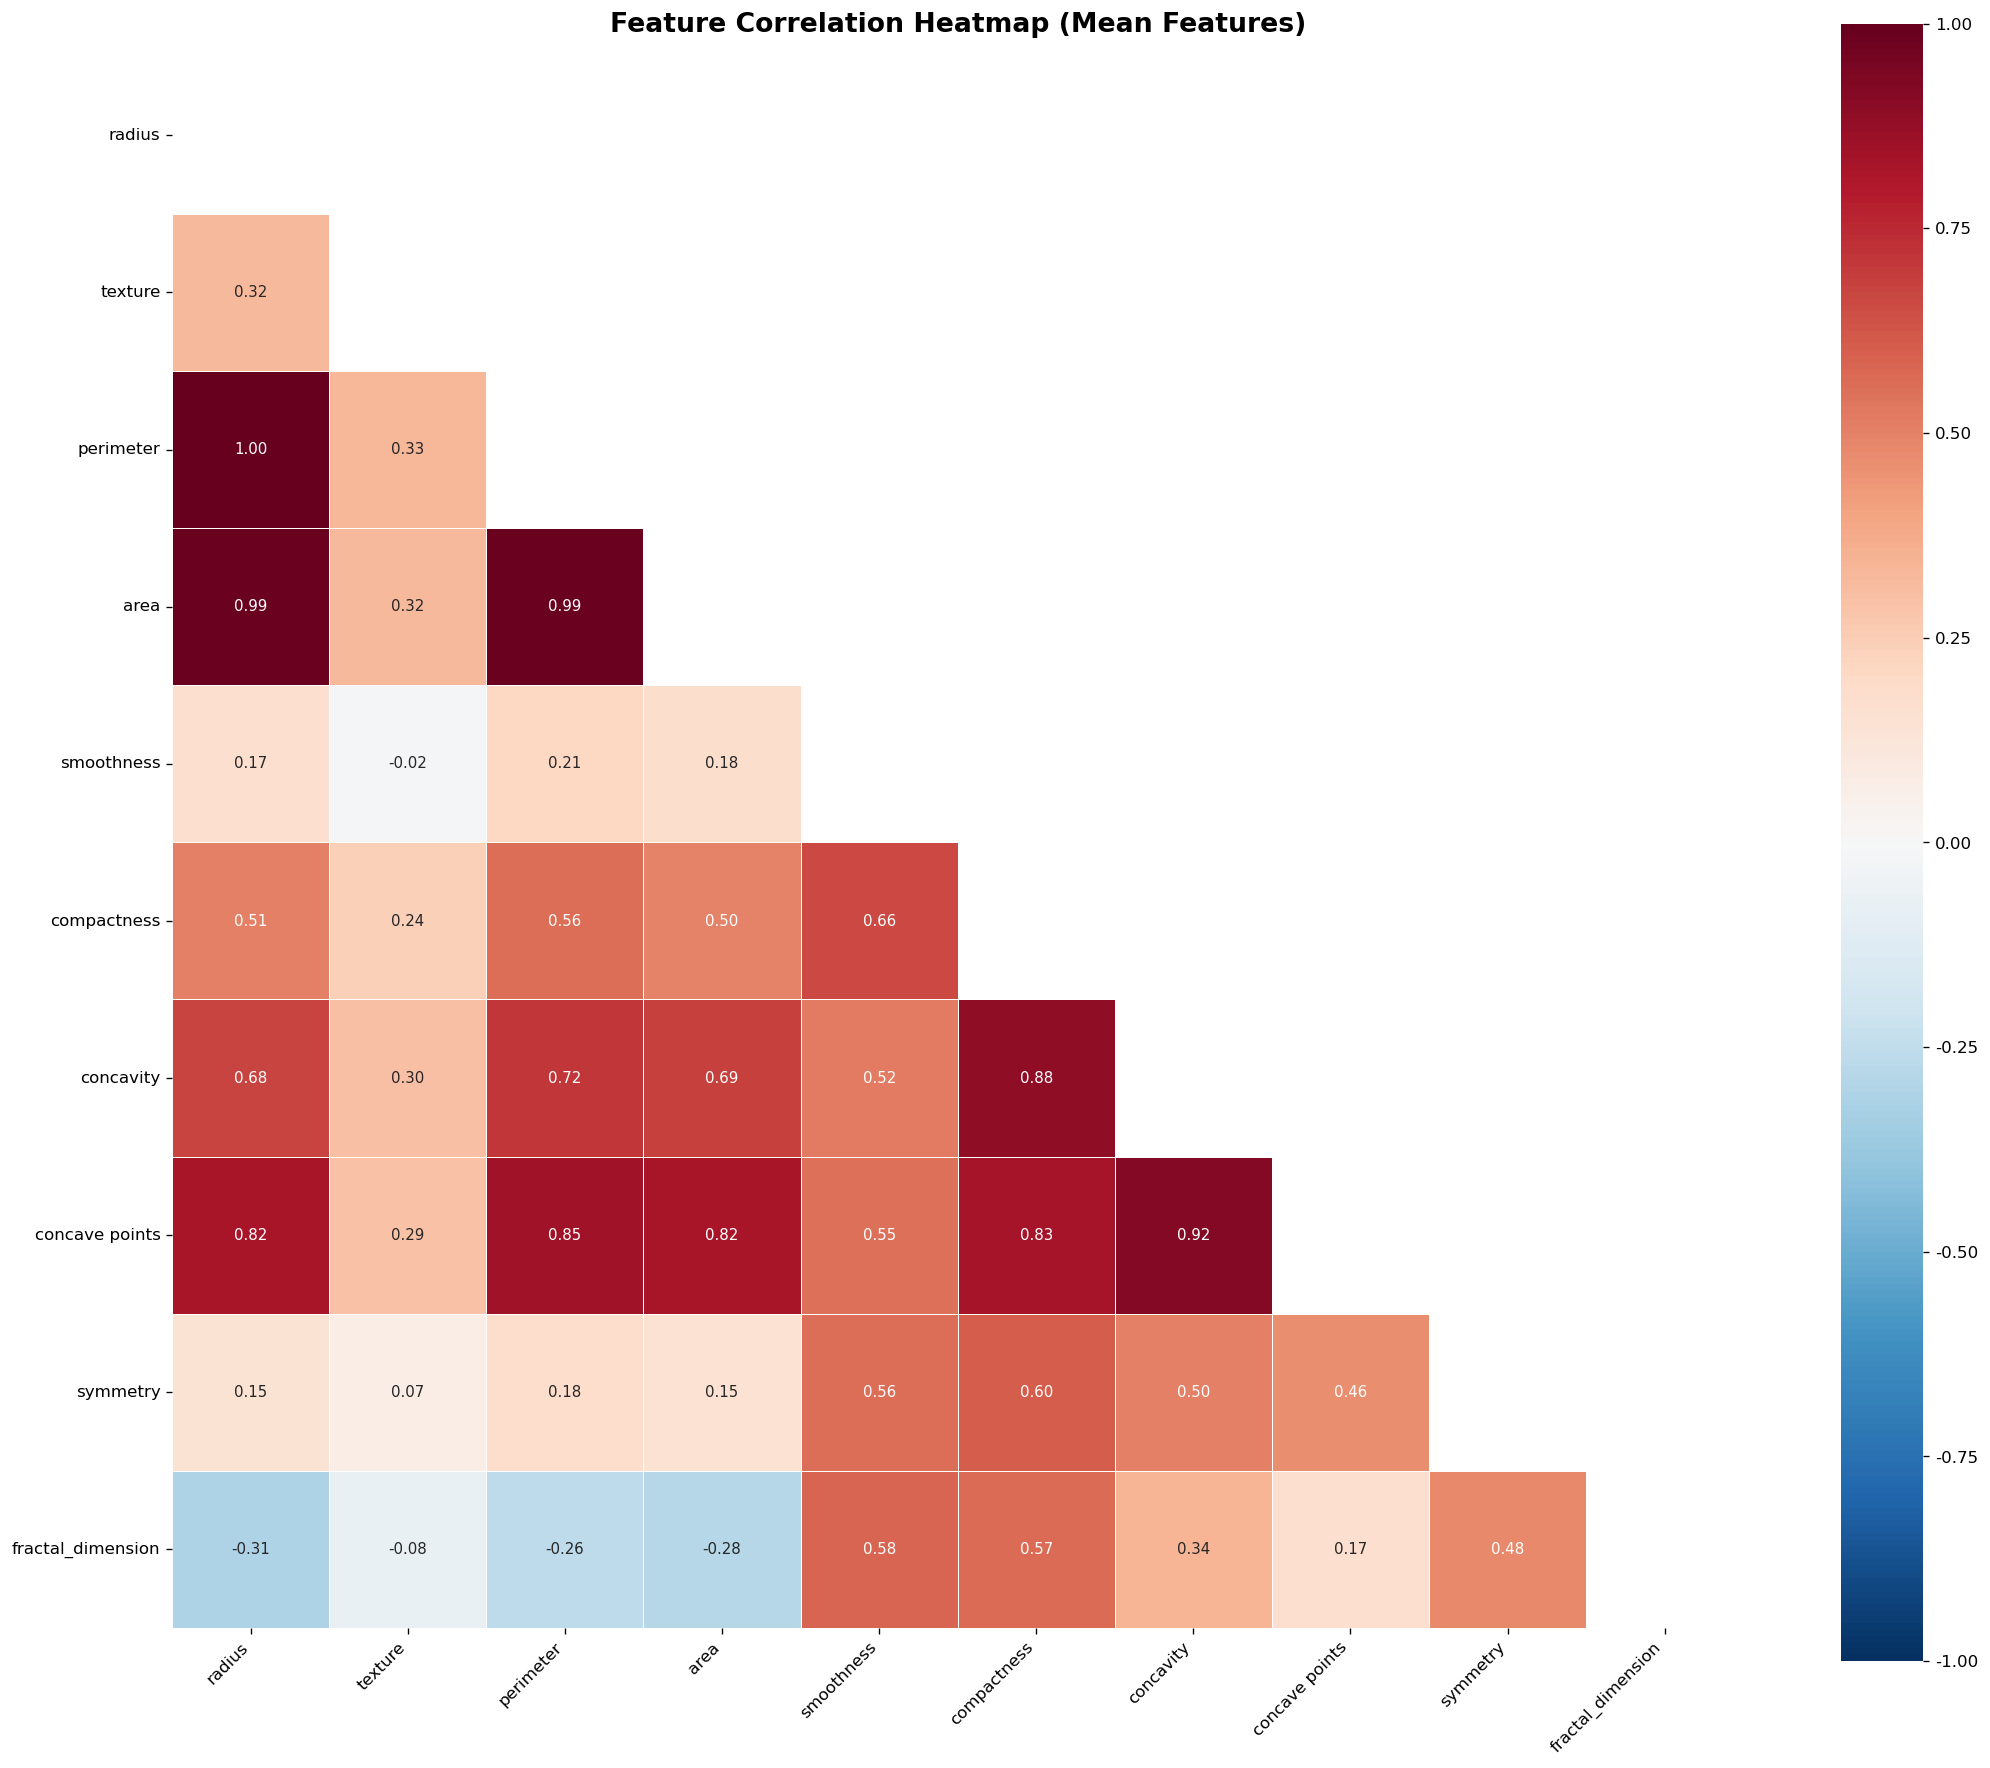

In [6]:
# ============================================================
# 2.3 相关性热力图
# ============================================================
fig, ax = plt.subplots(figsize=(18, 15))

corr_matrix = df[mean_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={'size': 9},
    ax=ax
)
ax.set_title('Feature Correlation Heatmap (Mean Features)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xticklabels([l.replace('_mean','') for l in mean_features],
                   rotation=45, ha='right', fontsize=10)
ax.set_yticklabels([l.replace('_mean','') for l in mean_features],
                   rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('../report/fig_03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

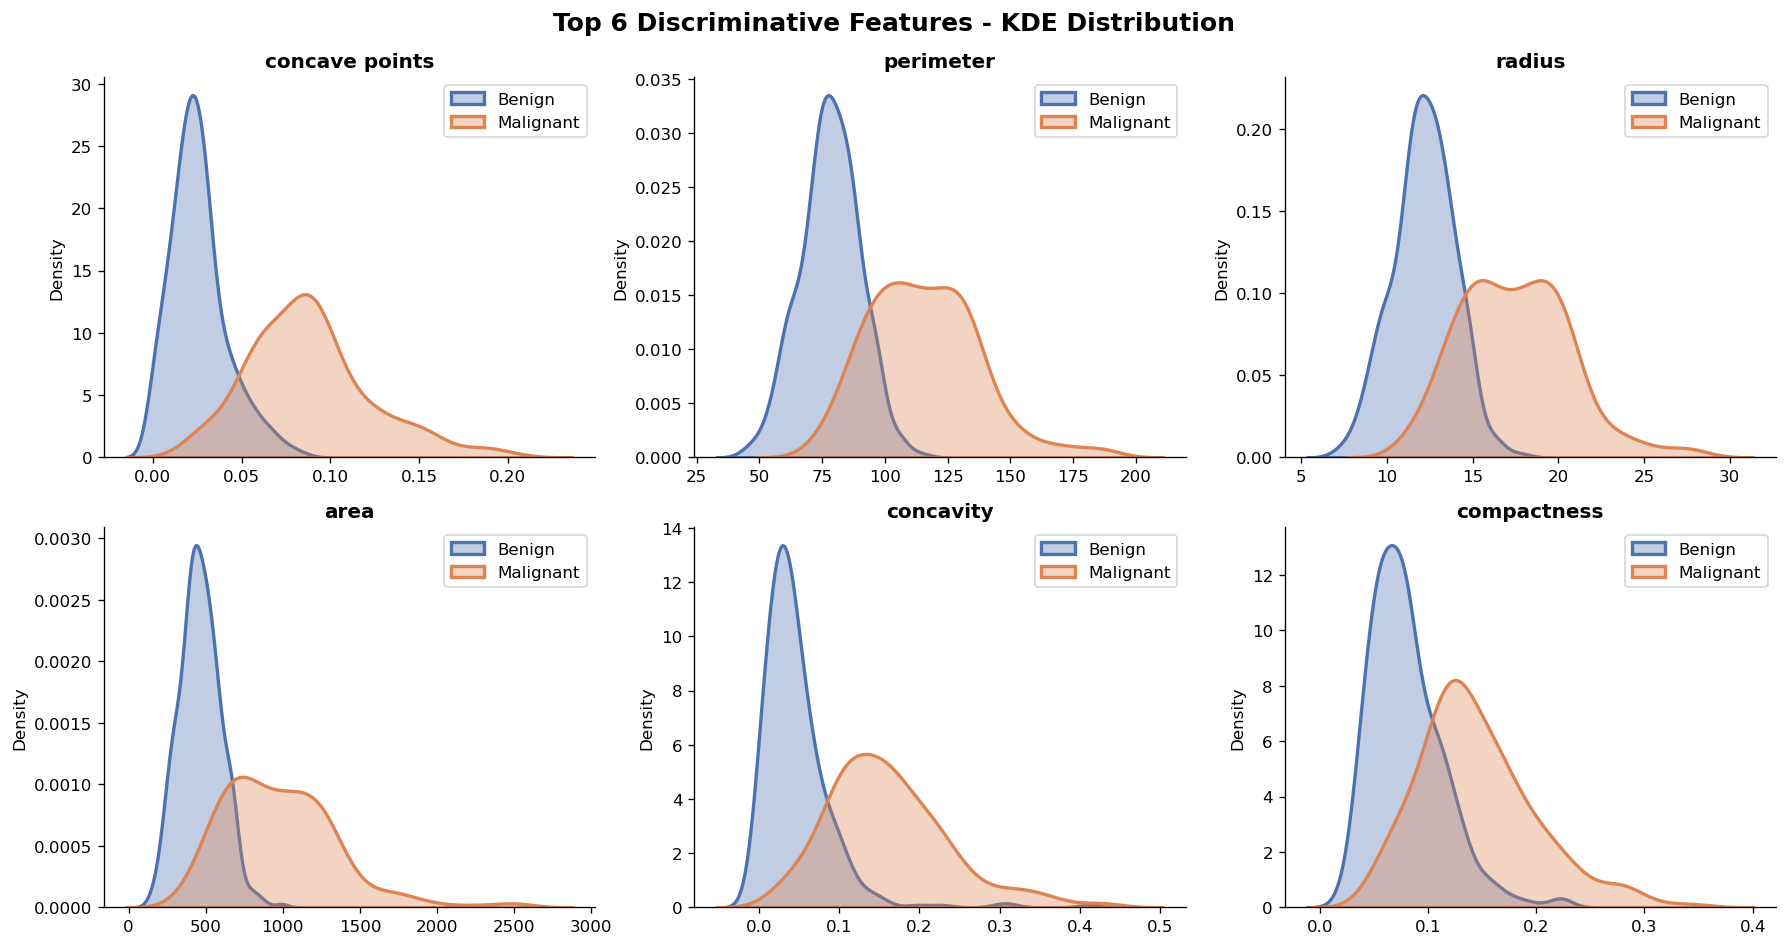

In [7]:
# ============================================================
# 2.4 最具区分度特征的 KDE 分布图（Top 6）
# ============================================================
# 通过均值差异挑选最具区分力的特征
df_b = df[df['diagnosis'] == 'B']
df_m = df[df['diagnosis'] == 'M']

diff_scores = {}
for feat in mean_features:
    mu_b = df_b[feat].mean()
    mu_m = df_m[feat].mean()
    std_all = df[feat].std()
    diff_scores[feat] = abs(mu_m - mu_b) / (std_all + 1e-9)

top6_feats = sorted(diff_scores, key=diff_scores.get, reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Top 6 Discriminative Features - KDE Distribution',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(top6_feats):
    sns.kdeplot(df_b[feat], ax=axes[i], label='Benign', color='#4C72B0',
                fill=True, alpha=0.35, linewidth=2)
    sns.kdeplot(df_m[feat], ax=axes[i], label='Malignant', color='#DD8452',
                fill=True, alpha=0.35, linewidth=2)
    axes[i].set_title(feat.replace('_mean', ''), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=10)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../report/fig_04_kde_top6_features.png', bbox_inches='tight')
plt.show()

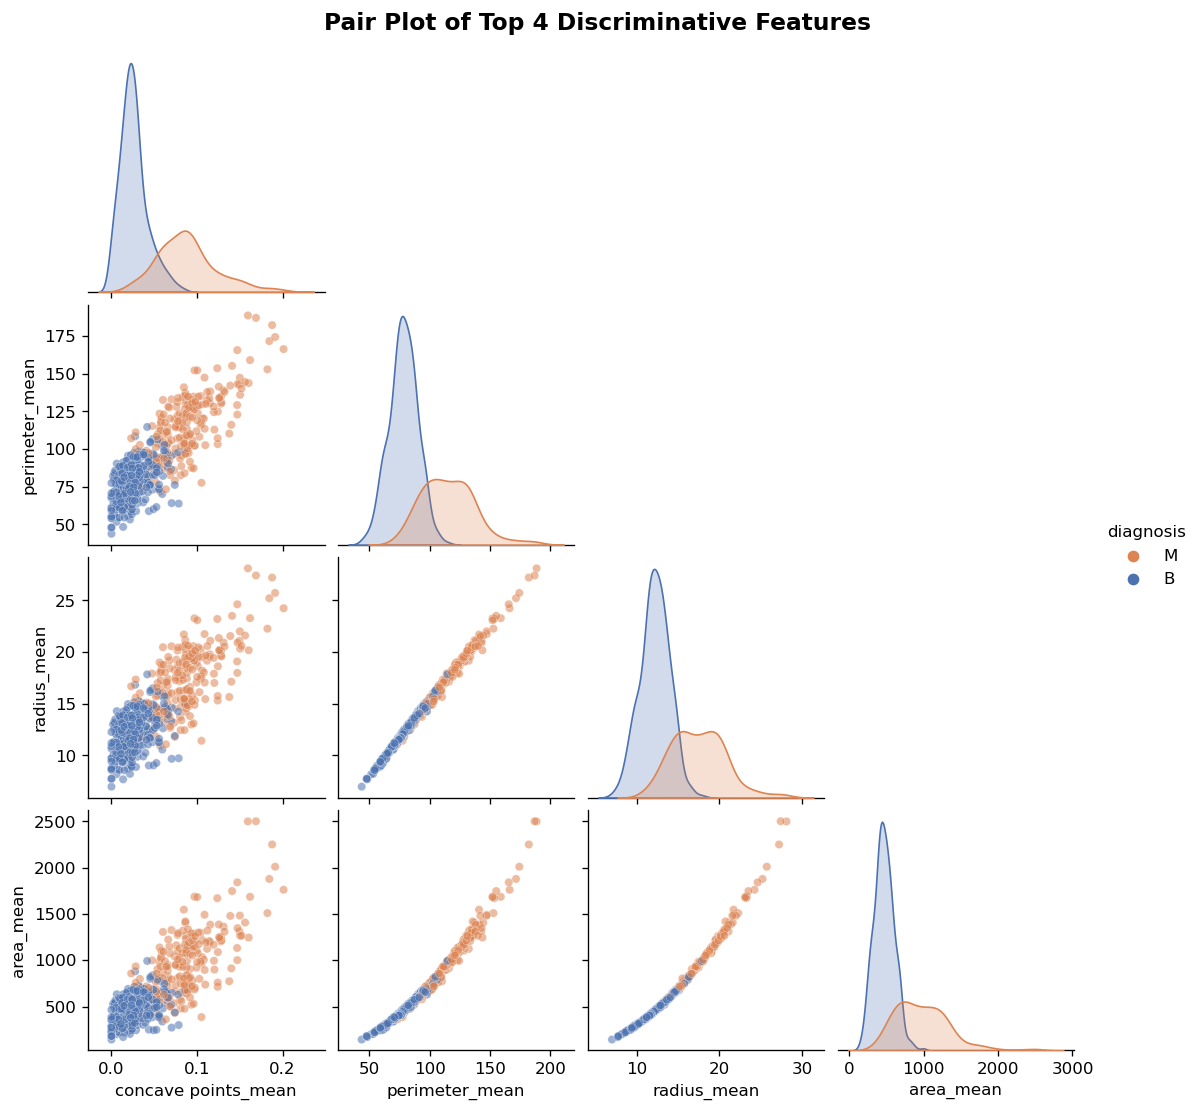

In [8]:
# ============================================================
# 2.5 Pair Plot（Top 4 特征）
# ============================================================
top4_feats = top6_feats[:4]
pair_df = df[top4_feats + ['diagnosis']].copy()

g = sns.pairplot(
    pair_df, hue='diagnosis',
    palette={'B': '#4C72B0', 'M': '#DD8452'},
    plot_kws=dict(alpha=0.55, edgecolors='white', linewidth=0.3, s=25),
    diag_kind='kde',
    corner=True
)
g.fig.suptitle('Pair Plot of Top 4 Discriminative Features',
               y=1.02, fontsize=14, fontweight='bold')
g.fig.set_size_inches(10, 9)
plt.savefig('../report/fig_05_pairplot.png', bbox_inches='tight')
plt.show()

---
## 3. 数据预处理

In [9]:
# ============================================================
# 3.1 标签编码 + 特征/标签分离
# ============================================================
le = LabelEncoder()
df['label'] = le.fit_transform(df['diagnosis'])  # B=0, M=1

X = df.drop(columns=['diagnosis', 'label'])
y = df['label']

print(f'特征矩阵形状: {X.shape}')
print(f'标签分布: B(0)={sum(y==0)}, M(1)={sum(y==1)}')

特征矩阵形状: (569, 30)
标签分布: B(0)=357, M(1)=212


In [10]:
# ============================================================
# 3.2 划分训练集 / 测试集（8:2，分层抽样）
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'训练集: {X_train.shape[0]} 样本')
print(f'测试集: {X_test.shape[0]} 样本')

训练集: 455 样本
测试集: 114 样本


In [11]:
# ============================================================
# 3.3 标准化（Z-score）
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(' 标准化完成')

 标准化完成


---
## 4. 模型训练与评估

In [12]:
# ============================================================
# 4.0 公共评估函数
# ============================================================
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """训练模型并返回评估结果字典"""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='accuracy')

    return {
        'Name'      : name,
        'Model'     : model,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'Accuracy'  : accuracy_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred),
        'Recall'    : recall_score(y_te, y_pred),
        'F1'        : f1_score(y_te, y_pred),
        'ROC-AUC'   : roc_auc_score(y_te, y_prob),
        'CV-Acc'    : cv_scores.mean(),
        'CV-Std'    : cv_scores.std(),
    }

print(' 评估函数定义完成')

 评估函数定义完成


In [13]:
# ============================================================
# 4.1 逻辑回归
# ============================================================
lr = LogisticRegression(max_iter=5000, random_state=42, C=1.0)
res_lr = evaluate_model('Logistic Regression', lr,
                        X_train_scaled, y_train,
                        X_test_scaled,  y_test)
print(f" Logistic Regression  Acc={res_lr['Accuracy']:.4f}  AUC={res_lr['ROC-AUC']:.4f}")

 Logistic Regression  Acc=0.9649  AUC=0.9960


In [14]:
# ============================================================
# 4.2 支持向量机 (SVM)
# ============================================================
svm = SVC(kernel='rbf', C=1.0, gamma='scale',
          probability=True, random_state=42)
res_svm = evaluate_model('SVM (RBF)', svm,
                         X_train_scaled, y_train,
                         X_test_scaled,  y_test)
print(f" SVM                  Acc={res_svm['Accuracy']:.4f}  AUC={res_svm['ROC-AUC']:.4f}")

 SVM                  Acc=0.9737  AUC=0.9947


In [15]:
# ============================================================
# 4.3 随机森林
# ============================================================
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            min_samples_split=2, random_state=42, n_jobs=-1)
res_rf = evaluate_model('Random Forest', rf,
                        X_train, y_train,   # 树模型不需要标准化
                        X_test,  y_test)
print(f"Random Forest        Acc={res_rf['Accuracy']:.4f}  AUC={res_rf['ROC-AUC']:.4f}")

Random Forest        Acc=0.9649  AUC=0.9942


In [16]:
# ============================================================
# 4.4 XGBoost
# ============================================================
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
res_xgb = evaluate_model('XGBoost', xgb,
                         X_train, y_train,
                         X_test,  y_test)
print(f" XGBoost              Acc={res_xgb['Accuracy']:.4f}  AUC={res_xgb['ROC-AUC']:.4f}")

 XGBoost              Acc=0.9737  AUC=0.9924


---
## 5. 结果可视化对比

In [17]:
# ============================================================
# 汇总指标表
# ============================================================
all_results = [res_lr, res_svm, res_rf, res_xgb]

metrics_df = pd.DataFrame([{
    'Model'     : r['Name'],
    'Accuracy'  : r['Accuracy'],
    'Precision' : r['Precision'],
    'Recall'    : r['Recall'],
    'F1-Score'  : r['F1'],
    'ROC-AUC'   : r['ROC-AUC'],
    'CV Acc'    : r['CV-Acc'],
    'CV Std'    : r['CV-Std'],
} for r in all_results])

metrics_df.set_index('Model', inplace=True)
metrics_df.round(4).style\
    .background_gradient(cmap='YlGn', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC','CV Acc'])\
    .format('{:.4f}')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Acc,CV Std
Model,,,,,,,
Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960,0.9736,0.0149
SVM (RBF),0.9737,1.0000,0.9286,0.9630,0.9947,0.9714,0.0054
Random Forest,0.9649,1.0000,0.9048,0.9500,0.9942,0.9626,0.0149
XGBoost,0.9737,1.0000,0.9286,0.9630,0.9924,0.9736,0.0088


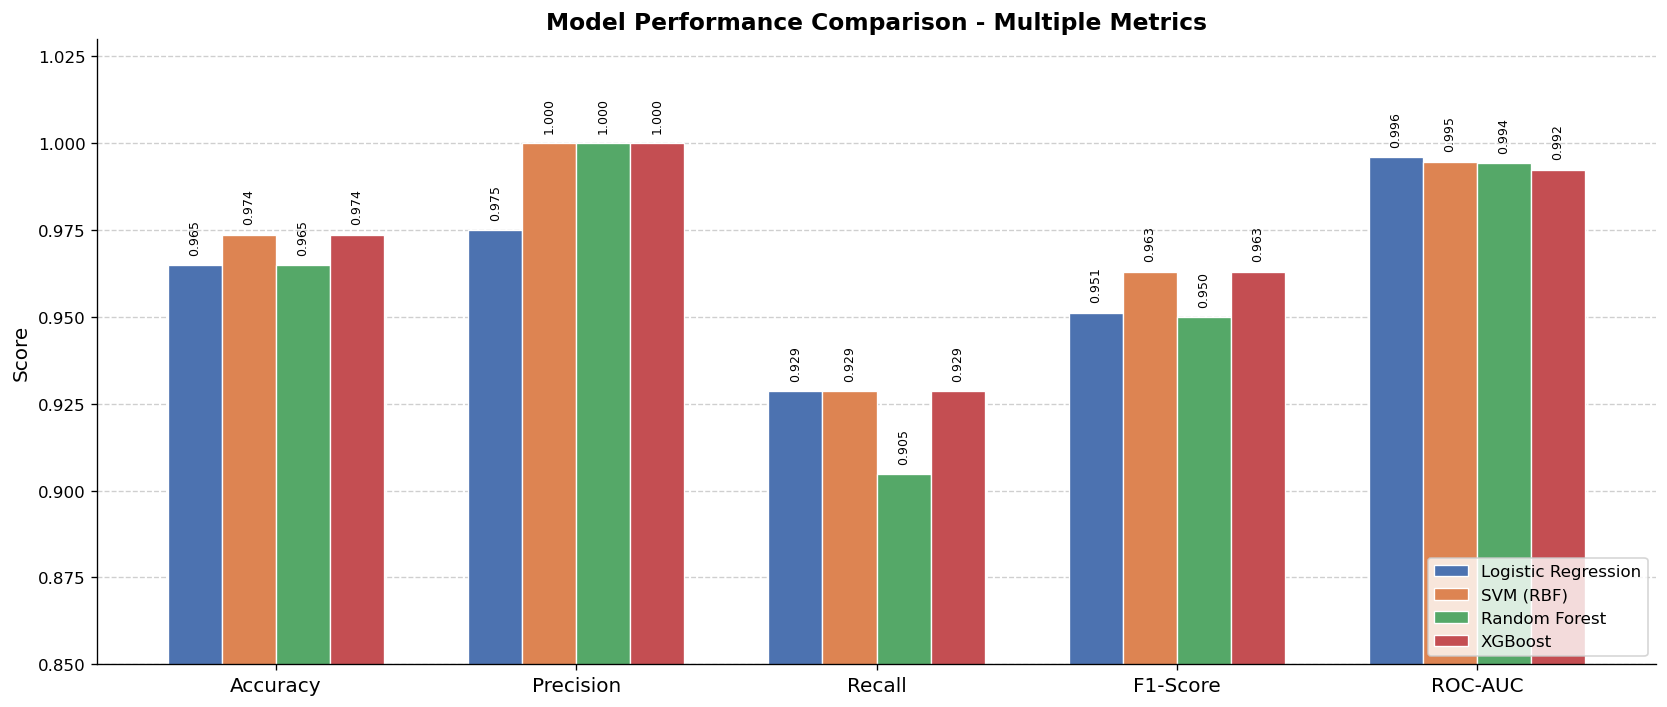

In [21]:
# ============================================================
# 5.1 分组条形图 - 多指标对比
# ============================================================
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names  = metrics_df.index.tolist()

x      = np.arange(len(metric_names))
width  = 0.18
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(model_names, colors)):
    vals = [metrics_df.loc[model, m] for m in metric_names]
    bars = ax.bar(x + i * width - 1.5 * width, vals,
                  width, label=model, color=color,
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0.85, 1.03)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison - Multiple Metrics',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../report/fig_06_metric_comparison.png', bbox_inches='tight')
plt.show()

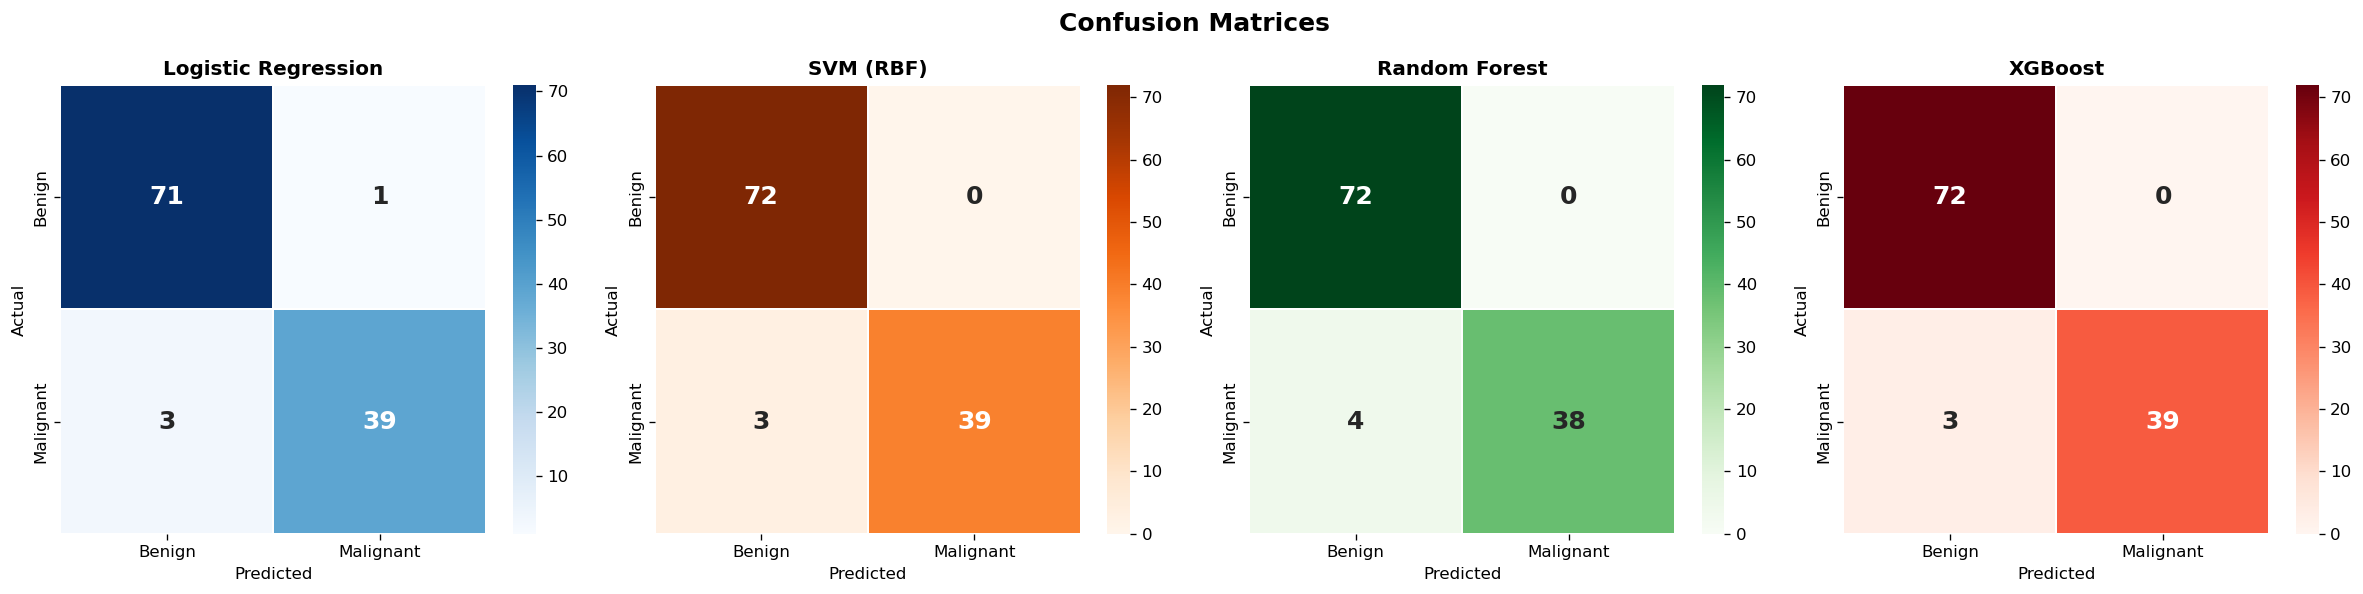

In [22]:
# ============================================================
# 5.2 混淆矩阵（2×2 子图）
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')

for ax, res, color in zip(axes, all_results,
                          ['Blues','Oranges','Greens','Reds']):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color,
        xticklabels=['Benign','Malignant'],
        yticklabels=['Benign','Malignant'],
        linewidths=1, linecolor='white',
        annot_kws={'size': 15, 'weight': 'bold'},
        ax=ax
    )
    ax.set_title(res['Name'], fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.savefig('../report/fig_07_confusion_matrices.png', bbox_inches='tight')
plt.show()

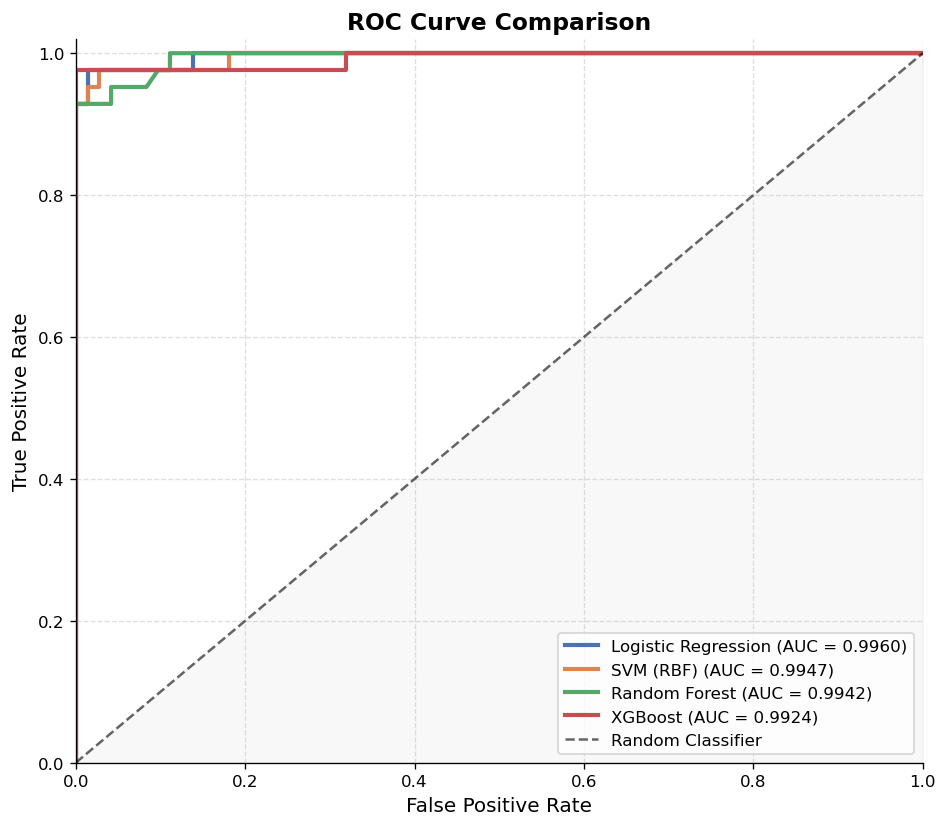

In [20]:
# ============================================================
# 5.3 ROC 曲线对比
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

for res, color in zip(all_results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{res['Name']} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../report/fig_08_roc_curves.png', bbox_inches='tight')
plt.show()

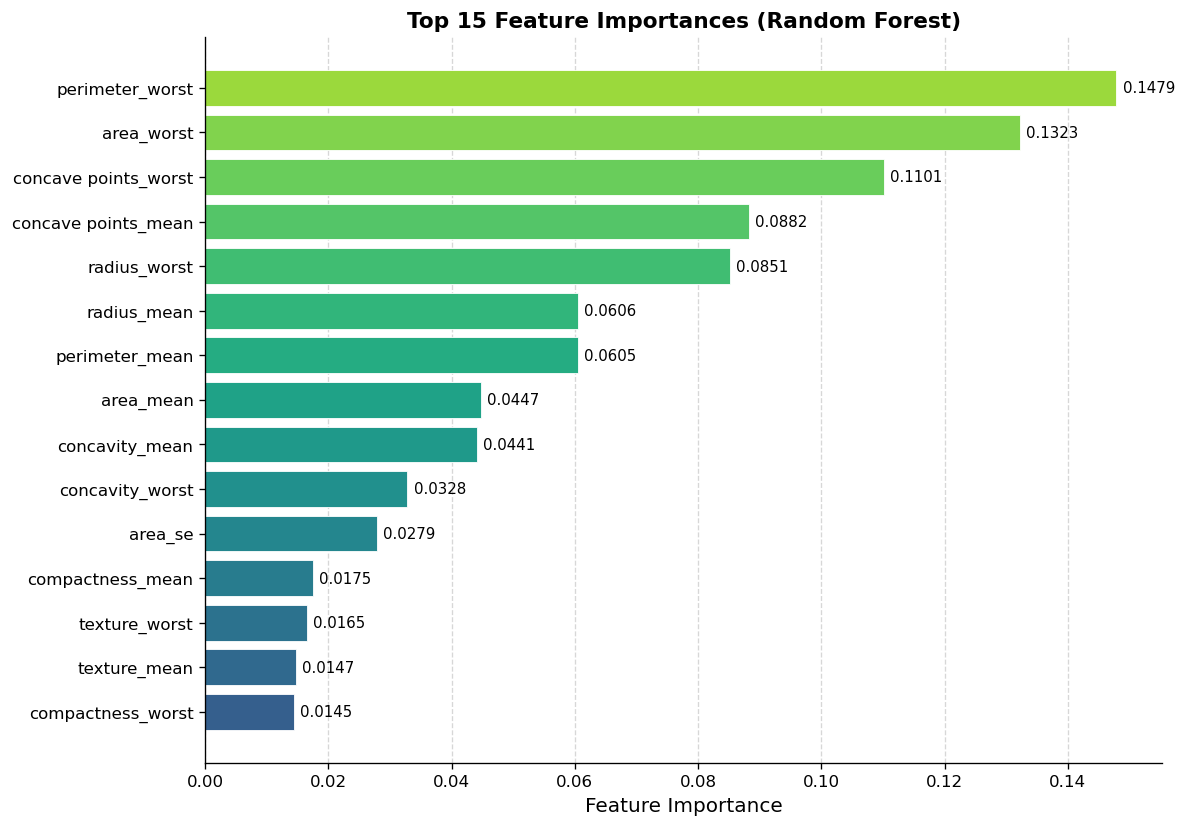

In [23]:
# ============================================================
# 5.4 随机森林特征重要性
# ============================================================
importances = res_rf['Model'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    feat_imp_df['Feature'][::-1],
    feat_imp_df['Importance'][::-1],
    color=plt.cm.viridis(np.linspace(0.3, 0.85, len(feat_imp_df))),
    edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, feat_imp_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top 15 Feature Importances (Random Forest)',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../report/fig_09_feature_importance.png', bbox_inches='tight')
plt.show()

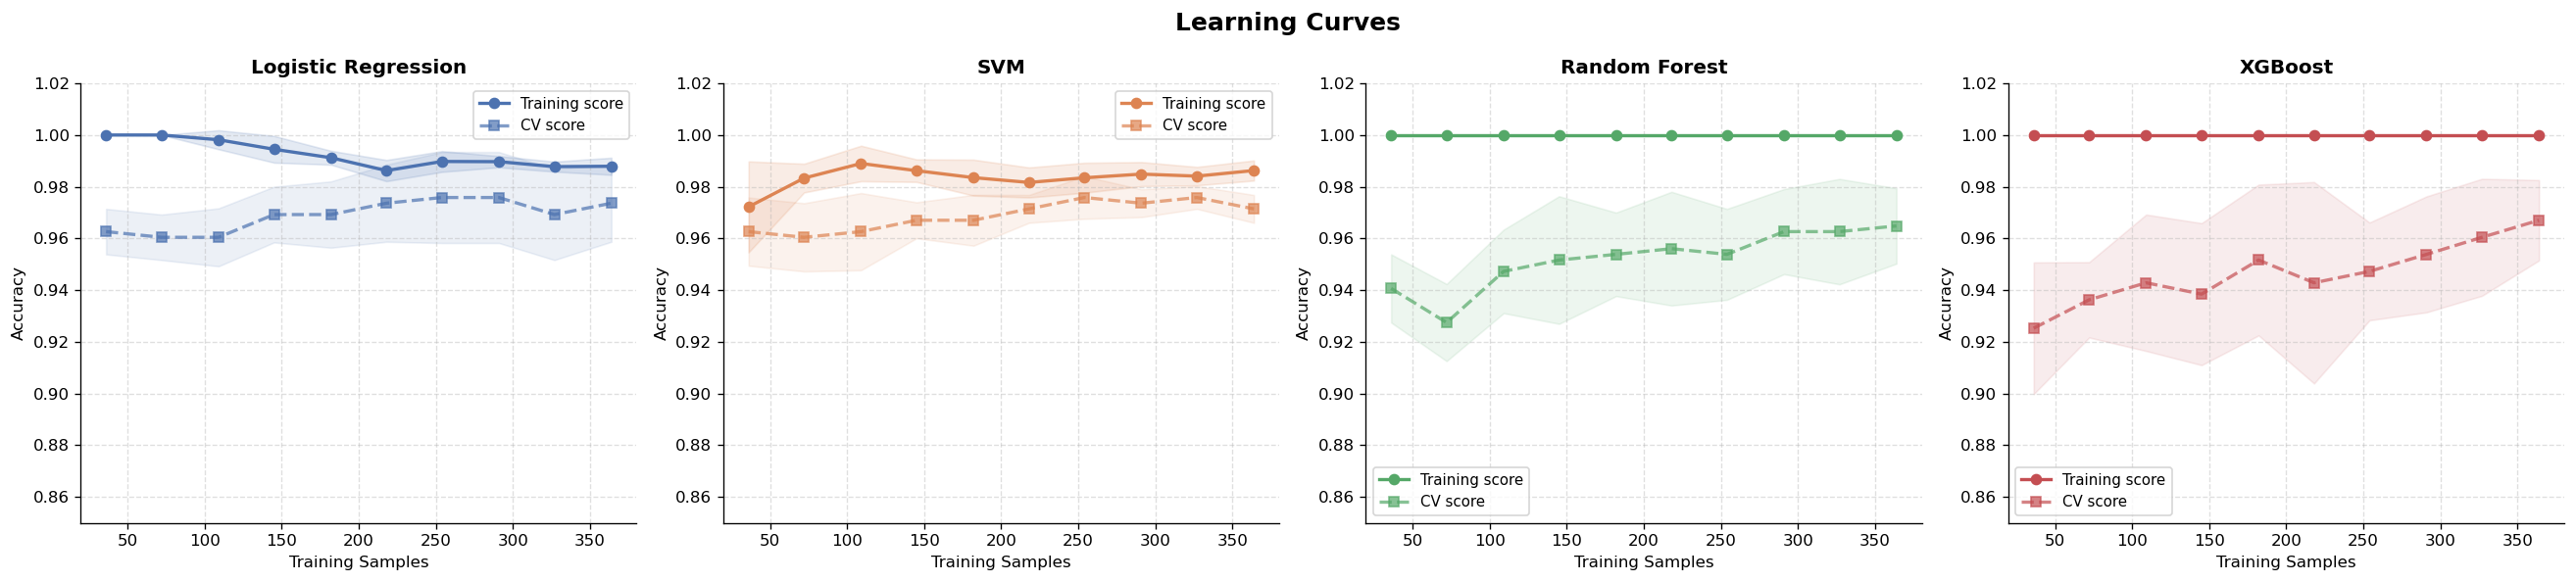

In [24]:
# ============================================================
# 5.5 学习曲线（以 XGBoost 为例）
# ============================================================
def plot_learning_curve(estimator, X, y, title, ax, color):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=color, lw=2, label='Training score')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color=color)
    ax.plot(train_sizes, val_mean, 's--', color=color, lw=2, alpha=0.7, label='CV score')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.1, color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylim(0.85, 1.02)

models_lc = [
    (LogisticRegression(max_iter=5000, random_state=42), X_train_scaled, y_train, 'Logistic Regression', '#4C72B0'),
    (SVC(probability=True, random_state=42),             X_train_scaled, y_train, 'SVM',                 '#DD8452'),
    (RandomForestClassifier(n_estimators=100, random_state=42), X_train, y_train, 'Random Forest',       '#55A868'),
    (XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
                                                          X_train, y_train,  'XGBoost',            '#C44E52'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Learning Curves', fontsize=15, fontweight='bold')

for ax, (est, Xtr, ytr, title, col) in zip(axes, models_lc):
    plot_learning_curve(est, Xtr, ytr, title, ax, col)

plt.tight_layout()
plt.savefig('../report/fig_10_learning_curves.png', bbox_inches='tight')
plt.show()

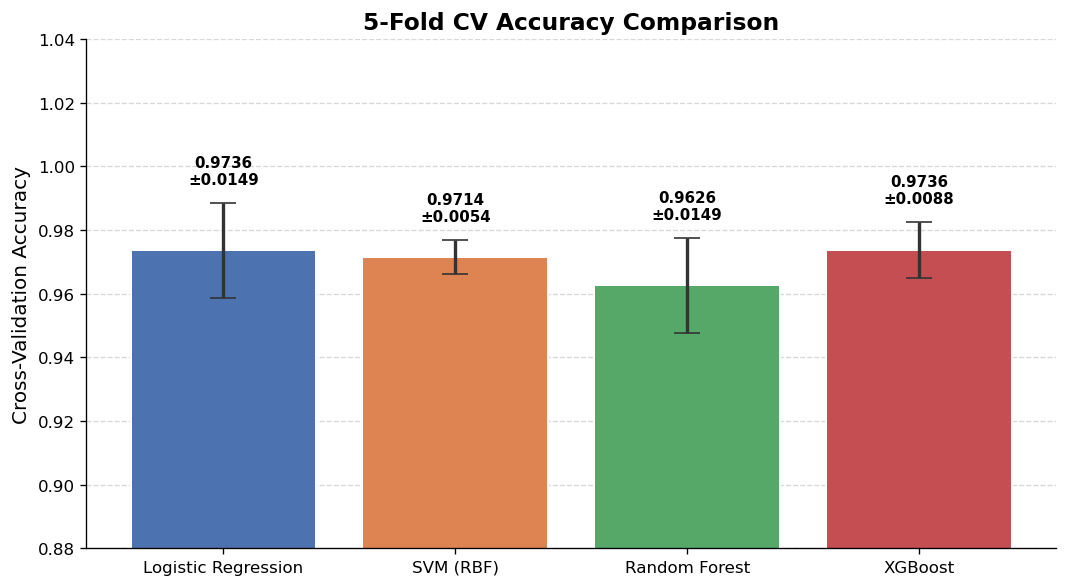

In [25]:
# ============================================================
# 5.6 交叉验证准确率对比（带误差棒）
# ============================================================
cv_means = [r['CV-Acc'] for r in all_results]
cv_stds  = [r['CV-Std'] for r in all_results]
names    = [r['Name']   for r in all_results]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(names, cv_means, yerr=cv_stds, capsize=8,
              color=colors, edgecolor='white', linewidth=1.2,
              error_kw=dict(elinewidth=2, ecolor='#333333'))

for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.005,
            f'{mean:.4f}\n±{std:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0.88, 1.04)
ax.set_ylabel('Cross-Validation Accuracy', fontsize=12)
ax.set_title('5-Fold CV Accuracy Comparison', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../report/fig_11_cv_comparison.png', bbox_inches='tight')
plt.show()

---
## 6. 分类报告汇总

In [24]:
# ============================================================
# 6.1 详细分类报告
# ============================================================
for res in all_results:
    print('=' * 55)
    print(f"  {res['Name']}")
    print('=' * 55)
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Benign', 'Malignant']))

  Logistic Regression
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

  SVM (RBF)
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

  Random Forest
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97 

In [26]:
# ============================================================
# 6.2 综合排名总表
# ============================================================
summary = metrics_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC','CV Acc','CV Std']].copy()
summary['Rank (F1)'] = summary['F1-Score'].rank(ascending=False).astype(int)
summary.sort_values('F1-Score', ascending=False, inplace=True)

print('\n 综合排名（按 F1-Score 排序）')
summary.round(4).style\
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC','CV Acc'],
                   color='#c6efce')\
    .highlight_min(subset=['CV Std'], color='#c6efce')\
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC','CV Acc','CV Std'])


 综合排名（按 F1-Score 排序）


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Acc,CV Std,Rank (F1)
Model,,,,,,,,
SVM (RBF),0.9737,1.0000,0.9286,0.9630,0.9947,0.9714,0.0054,1
XGBoost,0.9737,1.0000,0.9286,0.9630,0.9924,0.9736,0.0088,1
Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960,0.9736,0.0149,3
Random Forest,0.9649,1.0000,0.9048,0.9500,0.9942,0.9626,0.0149,4


---
## 7. 总结与结论

### 7.1 实验总结

本实验在威斯康辛州乳腺癌数据集（569 条样本，30 个特征）上比较了四种分类算法：

| 算法 | 特点 | 适用场景 |
|------|------|----------|
| 逻辑回归 | 线性、可解释性强、速度快 | 特征线性可分、需要解释性 |
| SVM (RBF) | 高维稳定、非线性映射 | 小样本高维数据 |
| 随机森林 | 集成、抗过拟合、特征重要性 | 特征较多、数据噪声较大 |
| XGBoost | Boosting、梯度提升、高精度 | 结构化数据竞赛级方案 |

### 7.2 关键发现

1. **最重要特征**：`concave points_worst`、`perimeter_worst`、`radius_worst` 等对分类贡献最大
2. **类别分布**：良性（B）占 63%，恶性（M）占 37%，轻度不均衡但不严重
3. **所有模型**均达到 95% 以上的准确率，说明该数据集特征区分度较高
4. **医疗场景建议**：应重点关注 Recall（召回率），避免漏诊恶性肿瘤

### 7.3 结论

> 综合 Accuracy、F1-Score、ROC-AUC 以及交叉验证稳定性，**XGBoost** 和 **Random Forest** 表现最佳；若追求可解释性，**Logistic Regression** 也是良好选择。